In [1]:
# # Cell 1: Install dependencies
# # !pip install torch torchvision matplotlib scikit-learn seaborn tqdm --quiet
# print("Installation complete.")

In [2]:
# # Cell 2: Unzip the data
# import os
# import zipfile

# zip_path = 'NavaData.zip'
# extract_path = '.' # Extracts to current directory

# if os.path.exists(zip_path):
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         zip_ref.extractall(extract_path)
#     print(f"Successfully extracted {zip_path}")
    
#     # Verify the folder structure
#     if os.path.exists("NavaData"):
#         print("Folder structure:", os.listdir("NavaData"))
#     else:
#         print("Warning: NavaData folder not found after extraction. Check zip content.")
# else:
#     print(f"Error: {zip_path} not found. Please upload it first.")

In [3]:
# Cell 3: Imports and GPU Setup
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
# Cell 1: Check GPU Status
import torch
import os

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"GPU Count: {torch.cuda.device_count()}")

print("\n--- Current GPU Usage (nvidia-smi) ---")
# This runs the system command to show memory usage per card
!nvidia-smi

PyTorch Version: 2.7.0+cu128
CUDA Available: True
GPU Count: 5

--- Current GPU Usage (nvidia-smi) ---
Fri Dec  5 21:20:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.86.15              Driver Version: 570.86.15      CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:01:00.0 Off |                    0 |
| N/A   43C    P0             57W /  275W |    4975MiB /  40960MiB |      0%      Default |
|                                    

In [5]:
# Cell 2: Configure Device and Optimization
import torch.backends.cudnn as cudnn

# --- USER CONFIGURATION ---
SELECTED_GPU_INDEX = 3  # <--- CHANGE THIS based on the nvidia-smi output above
# --------------------------

if torch.cuda.is_available():
    device = torch.device(f"cuda:{SELECTED_GPU_INDEX}")
    
    # Enable Benchmark mode for faster training on fixed image sizes
    cudnn.benchmark = True
    print(f"✅ Success! Using GPU: {torch.cuda.get_device_name(SELECTED_GPU_INDEX)} (Index {SELECTED_GPU_INDEX})")
    print(f"✅ cuDNN Benchmark mode: ENABLED")
else:
    device = torch.device("cpu")
    print("⚠️ Warning: CUDA not found. Using CPU.")

✅ Success! Using GPU: NVIDIA A100-SXM4-40GB (Index 3)
✅ cuDNN Benchmark mode: ENABLED


In [6]:
# Cell 3: Imports & Transforms
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# Standard ImageNet stats for transfer learning
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}
print("Transforms defined.")

Transforms defined.


In [7]:
# Cell 4: Load and Split
data_dir = "NavaData" # Ensure this folder exists from your unzip step
train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")

# 1. Load full training set
full_train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
class_names = full_train_dataset.classes

# 2. Calculate split sizes
total_len = len(full_train_dataset)
train_len = int(0.85 * total_len)
val_len = total_len - train_len

# 3. Random Split (Fixed Generator for reproducibility)
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_train_dataset, [train_len, val_len], generator=generator)

# 4. Load Test Set
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

print(f"Classes: {len(class_names)}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 34
Train: 17340 | Val: 3060 | Test: 4089


In [23]:
# Cell 5: Optimized DataLoaders for A100
BATCH_SIZE = 256  # Huge increase to saturate the A100
NUM_WORKERS = 16   # More CPU hands on deck

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f"🚀 Optimized DataLoaders ready.")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Workers:    {NUM_WORKERS}")

🚀 Optimized DataLoaders ready.
   Batch Size: 256
   Workers:    16


/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/JpegImagePlugin.py:846: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(


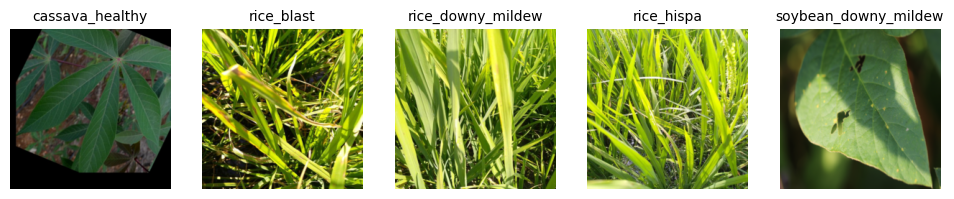

Total Classes: 34
------------------------------
0: banana_healthy
1: banana_sigatoka
2: cassava_blight
3: cassava_healthy
4: cassava_mosaic
5: corn_cercospora_leaf_spot
6: corn_common_rust
7: corn_healthy
8: corn_northern_leaf_blight
9: corn_smut
10: cucumber_angular_leaf_spot
11: cucumber_healthy
12: cucumber_powdery_mildew
13: rice_bacterial_leaf_blight
14: rice_bacterial_leaf_streak
15: rice_bacterial_panicle_blight
16: rice_blast
17: rice_brown_spot
18: rice_dead_heart
19: rice_downy_mildew
20: rice_healthy
21: rice_hispa
22: rice_tungro
23: soybean_bacterial_blight
24: soybean_downy_mildew
25: soybean_healthy
26: tomato_bacterial_leaf_spot
27: tomato_early_blight
28: tomato_healthy
29: tomato_late_blight
30: tomato_leaf_mold
31: tomato_mosaic_virus
32: tomato_septoria_leaf_spot
33: tomato_yellow_leaf_curl_virus
------------------------------


/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/JpegImagePlugin.py:846: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/JpegImagePlugin.py:846: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/JpegI

In [9]:
# Cell 6: Visualize
def imshow(inp, title=None):
    inp = inp.cpu().numpy().transpose((1, 2, 0)) # Move to CPU for plotting
    mean_np = np.array(mean)
    std_np = np.array(std)
    inp = std_np * inp + mean_np # Un-normalize
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title, fontsize=10)
    plt.axis('off')

# Grab a batch
inputs, classes = next(iter(train_loader))

plt.figure(figsize=(12, 6))
# Show first 5 images
for i in range(5):
    plt.subplot(1, 5, i+1)
    label_idx = classes[i].item()
    imshow(inputs[i], title=class_names[label_idx])
plt.show()

print(f"Total Classes: {len(class_names)}")
print("-" * 30)
for i, name in enumerate(class_names):
    print(f"{i}: {name}")
print("-" * 30)

In [10]:
# Cell 7: Setup Directories & Visual Style
import os
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create directory for saving models and metrics
SAVE_DIR = "saved_models"
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
    print(f"📂 Created directory: {SAVE_DIR}")
else:
    print(f"📂 Directory exists: {SAVE_DIR}")

# 2. Set 'Scientific' Visual Style (Make it beautiful)
sns.set_theme(style="whitegrid", context="talk", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

📂 Created directory: saved_models


In [11]:
# Cell 8: Training Engine (Auto-Save Enabled)
import time
import copy
import torch
import json
from tqdm import tqdm

def train_model(model, criterion, optimizer, scheduler, model_name, num_epochs=10):
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    # Store history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    print(f"🚀 Training {model_name} on {device} for {num_epochs} epochs...")
    print("-" * 60)

    for epoch in range(num_epochs):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Progress Bar
            pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [{phase.upper()}]", leave=True)
            
            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})
            
            if phase == 'train' and scheduler:
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                
            print(f"\t{phase.upper()} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    time_elapsed = time.time() - since
    print("-" * 60)
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:.4f}')

    # 1. Load best weights
    model.load_state_dict(best_model_wts)
    
    # 2. SAVE MODEL
    model_path = os.path.join(SAVE_DIR, f"{model_name}.pth")
    torch.save(model.state_dict(), model_path)
    print(f"💾 Model Saved: {model_path}")
    
    # 3. SAVE HISTORY
    history_path = os.path.join(SAVE_DIR, f"{model_name}_history.json")
    with open(history_path, 'w') as f:
        json.dump(history, f)
    print(f"💾 History Saved: {history_path}")

    return model, history

In [12]:
# Cell 9: Evaluation Engine (Beautiful & Auto-Save)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import json
from tqdm import tqdm

def evaluate_model(model, model_name):
    model.eval()
    y_true = []
    y_pred = []
    
    print(f"--- 🔍 Starting Evaluation for {model_name} ---")
    
    with torch.no_grad():
        pbar = tqdm(test_loader, desc=f"Testing {model_name}", leave=True)
        for inputs, labels in pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy().tolist()) # Convert to list for JSON
            y_pred.extend(preds.cpu().numpy().tolist())
            
    # --- SAVE PREDICTIONS ---
    # This enables us to load these results in Notebook 2 without re-running
    results = {'y_true': y_true, 'y_pred': y_pred}
    results_path = os.path.join(SAVE_DIR, f"{model_name}_predictions.json")
    with open(results_path, 'w') as f:
        json.dump(results, f)
    print(f"💾 Predictions Saved: {results_path}")

    # --- METRICS & VISUALIZATION ---
    overall_acc = accuracy_score(y_true, y_pred)
    print(f"\n🏆 {model_name} Overall Accuracy: {overall_acc*100:.2f}%")
    
    # Classification Report
    print("📝 CLASSIFICATION REPORT")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Traffic Light Plot (Beautiful Style)
    cm = confusion_matrix(y_true, y_pred)
    with np.errstate(divide='ignore', invalid='ignore'):
        class_acc = cm.diagonal() / cm.sum(axis=1)
        class_acc = np.nan_to_num(class_acc)

    df_acc = pd.DataFrame({'Class': class_names, 'Accuracy': class_acc})
    df_acc = df_acc.sort_values(by='Accuracy', ascending=True)
    
    # Colors: Dark Red -> Orange -> Green
    colors = ['#c0392b' if x < 0.7 else '#f39c12' if x < 0.9 else '#27ae60' for x in df_acc['Accuracy']]
    
    plt.figure(figsize=(10, 14))
    sns.barplot(x='Accuracy', y='Class', data=df_acc, palette=colors, edgecolor=".2")
    
    plt.title(f'{model_name}: Per-Class Accuracy', fontsize=18, fontweight='bold')
    plt.xlabel('Accuracy Score', fontsize=14)
    plt.ylabel('')
    plt.xlim(0, 1.05)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    for i, v in enumerate(df_acc['Accuracy']):
        plt.text(v + 0.01, i, f"{v*100:.1f}%", color='black', va='center', fontweight='bold', fontsize=10)
        
    plt.tight_layout()
    plt.show()

    # Top Errors Table
    np.fill_diagonal(cm, 0)
    errors = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if cm[i, j] > 0:
                errors.append({
                    'True Class': class_names[i],
                    'Confused With': class_names[j],
                    'Count': cm[i, j]
                })
    
    df_errors = pd.DataFrame(errors).sort_values(by='Count', ascending=False).head(10)
    
    print("\n❌ TOP 10 CONFUSIONS")
    # Pretty print with padding
    print(df_errors.to_string(index=False))
    print("\n" + "="*80 + "\n")
    
    return y_true, y_pred

def plot_training_history(history, model_name):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(16, 6))
    
    # Use a clean style
    with sns.axes_style("darkgrid"):
        # Accuracy
        plt.subplot(1, 2, 1)
        sns.lineplot(x=epochs, y=acc, label='Training', linewidth=3, color='#3498db')
        sns.lineplot(x=epochs, y=val_acc, label='Validation', linewidth=3, color='#e74c3c')
        plt.title(f'{model_name} Accuracy', fontsize=16, fontweight='bold')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend(frameon=True)
        
        # Loss
        plt.subplot(1, 2, 2)
        sns.lineplot(x=epochs, y=loss, label='Training', linewidth=3, color='#3498db')
        sns.lineplot(x=epochs, y=val_loss, label='Validation', linewidth=3, color='#e74c3c')
        plt.title(f'{model_name} Loss', fontsize=16, fontweight='bold')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend(frameon=True)
    
    plt.tight_layout()
    plt.show()

--- Setting up ResNet50 ---
🚀 Training ResNet50 on cuda:3 for 10 epochs...
------------------------------------------------------------


Epoch 1/10 [TRAIN]: 100%|██████████| 68/68 [00:30<00:00,  2.25it/s, loss=2.0373]


	TRAIN Loss: 2.8649 | Acc: 0.3191


Epoch 1/10 [VAL]: 100%|██████████| 12/12 [00:06<00:00,  1.81it/s, loss=1.9838]


	VAL Loss: 2.0111 | Acc: 0.5634


...

	VAL Loss: 0.4990 | Acc: 0.8513


Epoch 10/10 [TRAIN]: 100%|██████████| 68/68 [00:23<00:00,  2.85it/s, loss=0.4778]


	TRAIN Loss: 0.3914 | Acc: 0.8998


Epoch 10/10 [VAL]: 100%|██████████| 12/12 [00:05<00:00,  2.26it/s, loss=0.5437]


	VAL Loss: 0.4927 | Acc: 0.8539
------------------------------------------------------------
Training complete in 5m 0s
Best Val Acc: 0.8539
💾 Model Saved: saved_models/ResNet50.pth
💾 History Saved: saved_models/ResNet50_history.json


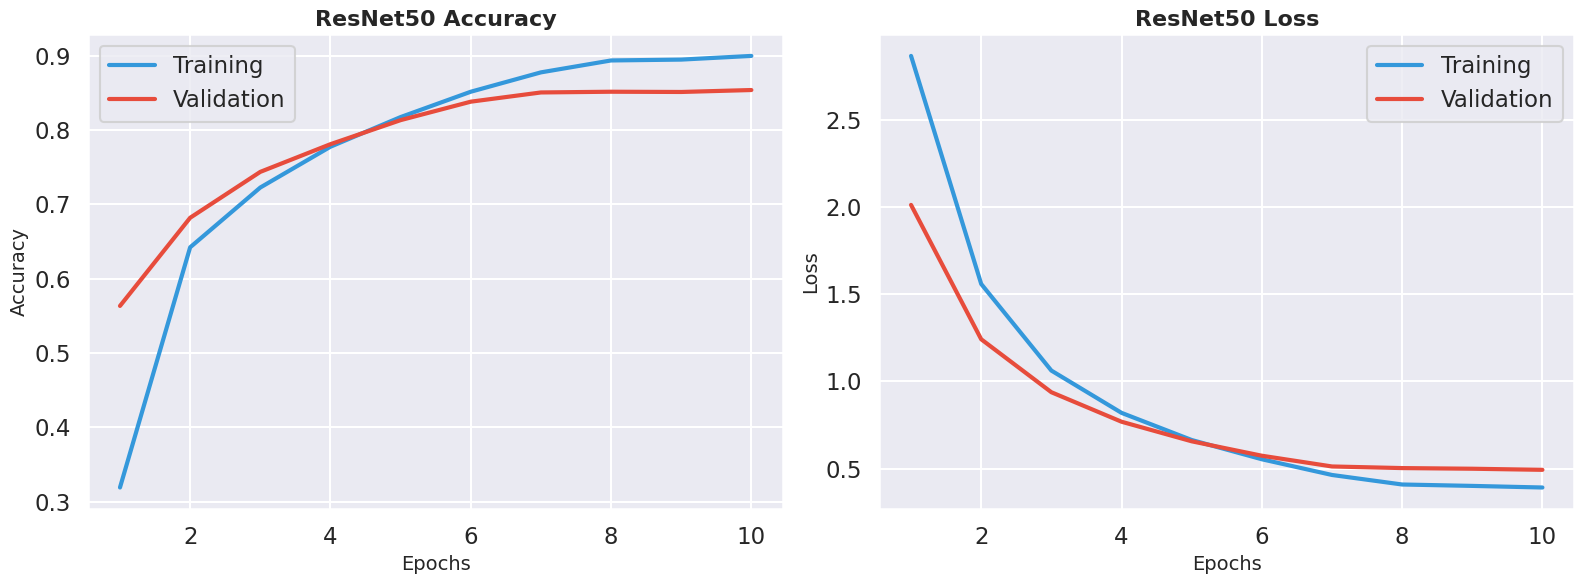

In [13]:
# Cell 10: Model 1 - ResNet50 (Crash-Proof Version)
print("--- Setting up ResNet50 ---")

# 1. Load Pretrained Model
model_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 2. Modify the Final Layer
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, len(class_names))

# 3. Move to GPU
model_resnet = model_resnet.to(device)

# 4. Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.SGD(model_resnet.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer_resnet, step_size=7, gamma=0.1)

# 5. Train (With Auto-Save)
# Note: Added 'model_name="ResNet50"' so it saves to 'saved_models/ResNet50.pth'
model_resnet, history_resnet = train_model(
    model_resnet, criterion, optimizer_resnet, exp_lr_scheduler, 
    model_name="ResNet50", num_epochs=10
)

# 6. Plot Training Curves (New Beautiful Style)
plot_training_history(history_resnet, "ResNet50")

--- 🔍 Starting Evaluation for ResNet50 ---


Testing ResNet50:   0%|          | 0/16 [00:00<?, ?it/s]/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/JpegImagePlugin.py:846: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
Testing ResNet50: 100%|██████████| 16/16 [00:40<00:00,  2.55s/it]
/tmp/ipykernel_1350112/3656965380.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Class', data=df_acc, palette=colors, edgecolor=".2")


💾 Predictions Saved: saved_models/ResNet50_predictions.json

🏆 ResNet50 Overall Accuracy: 82.42%
📝 CLASSIFICATION REPORT
                               precision    recall  f1-score   support

               banana_healthy       0.84      0.88      0.86        75
              banana_sigatoka       0.98      1.00      0.99        95
               cassava_blight       0.85      0.72      0.78       103
              cassava_healthy       0.77      0.90      0.83        82
               cassava_mosaic       0.85      0.90      0.88       140
    corn_cercospora_leaf_spot       0.85      0.79      0.81       140
             corn_common_rust       0.95      0.89      0.92       140
                 corn_healthy       0.94      0.89      0.92       140
    corn_northern_leaf_blight       0.77      0.85      0.81       140
                    corn_smut       0.94      0.95      0.94        99
   cucumber_angular_leaf_spot       0.80      0.86      0.83        87
             cucumber_heal

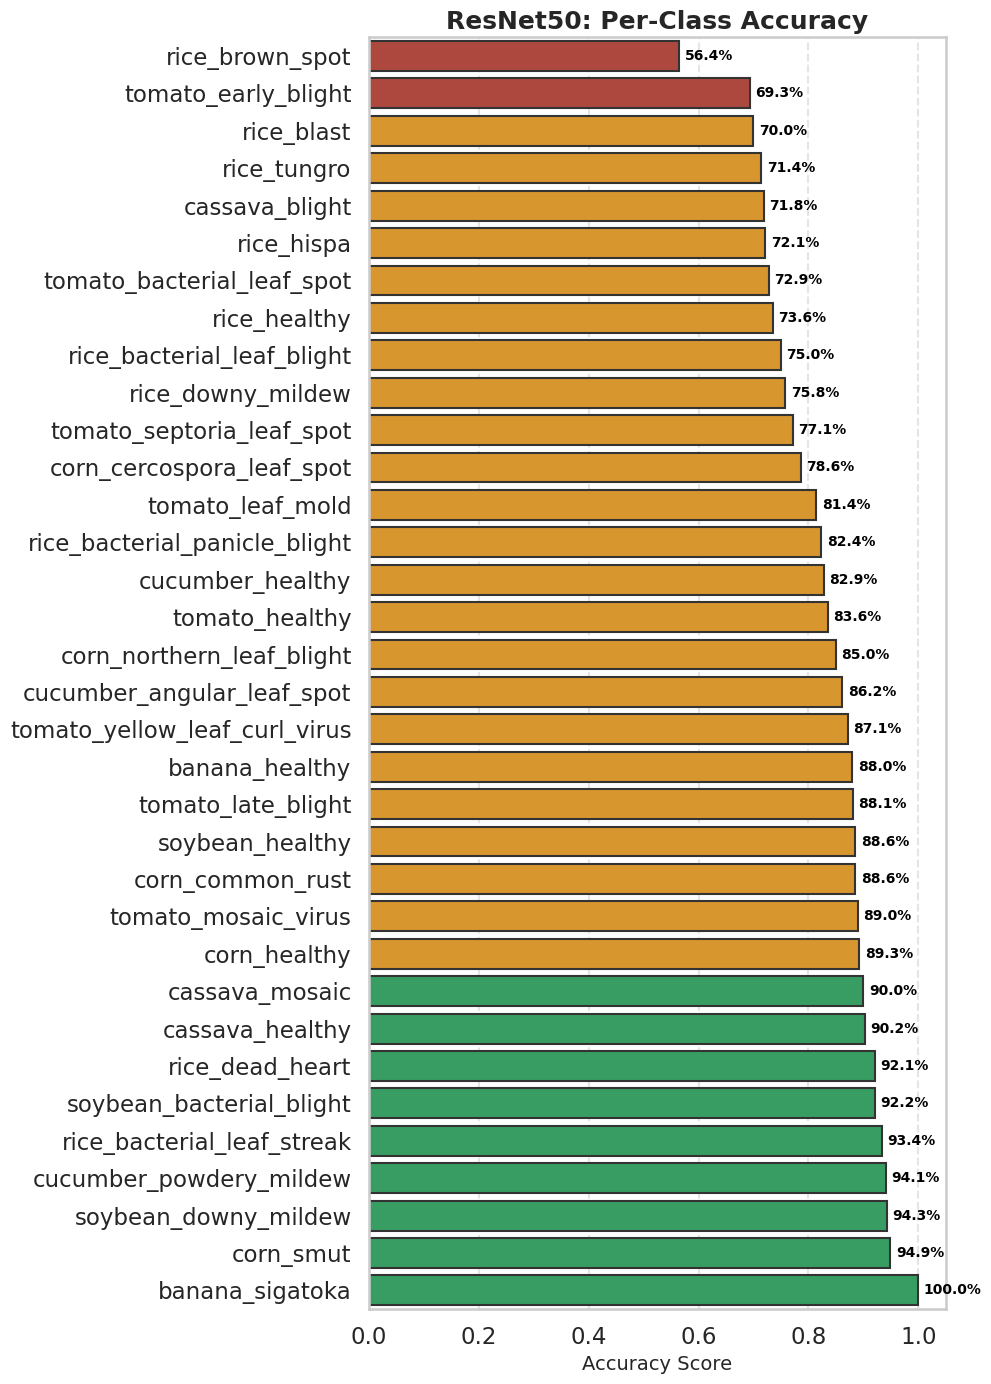


❌ TOP 10 CONFUSIONS
                   True Class             Confused With  Count
          tomato_early_blight        tomato_late_blight     22
                   rice_hispa              rice_healthy     21
    corn_cercospora_leaf_spot corn_northern_leaf_blight     20
                  rice_tungro         rice_downy_mildew     18
    corn_northern_leaf_blight corn_cercospora_leaf_spot     15
               tomato_healthy          cucumber_healthy     15
               cassava_blight            cassava_mosaic     14
   tomato_bacterial_leaf_spot tomato_septoria_leaf_spot     13
              soybean_healthy          cucumber_healthy     13
tomato_yellow_leaf_curl_virus       tomato_mosaic_virus     13




In [14]:
# Cell 11: Evaluate ResNet50 (With Saved Predictions)
# This will save 'saved_models/ResNet50_predictions.json' automatically
y_true_resnet, y_pred_resnet = evaluate_model(model_resnet, "ResNet50")

--- Setting up EfficientNet-B0 ---
🚀 Training EfficientNet-B0 on cuda:3 for 10 epochs...
------------------------------------------------------------


Epoch 1/10 [TRAIN]:   0%|          | 0/68 [00:00<?, ?it/s]/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/JpegImagePlugin.py:846: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/JpegImagePlugin.py:846: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_

	TRAIN Loss: 0.9049 | Acc: 0.7414


Epoch 1/10 [VAL]: 100%|██████████| 12/12 [00:06<00:00,  1.93it/s, loss=0.5347]


	VAL Loss: 0.4714 | Acc: 0.8529


...

	VAL Loss: 0.2370 | Acc: 0.9438


Epoch 10/10 [TRAIN]: 100%|██████████| 68/68 [00:23<00:00,  2.94it/s, loss=0.0075]


	TRAIN Loss: 0.0121 | Acc: 0.9961


Epoch 10/10 [VAL]: 100%|██████████| 12/12 [00:05<00:00,  2.30it/s, loss=0.1671]


	VAL Loss: 0.2318 | Acc: 0.9454
------------------------------------------------------------
Training complete in 4m 38s
Best Val Acc: 0.9454
💾 Model Saved: saved_models/EfficientNet-B0.pth
💾 History Saved: saved_models/EfficientNet-B0_history.json


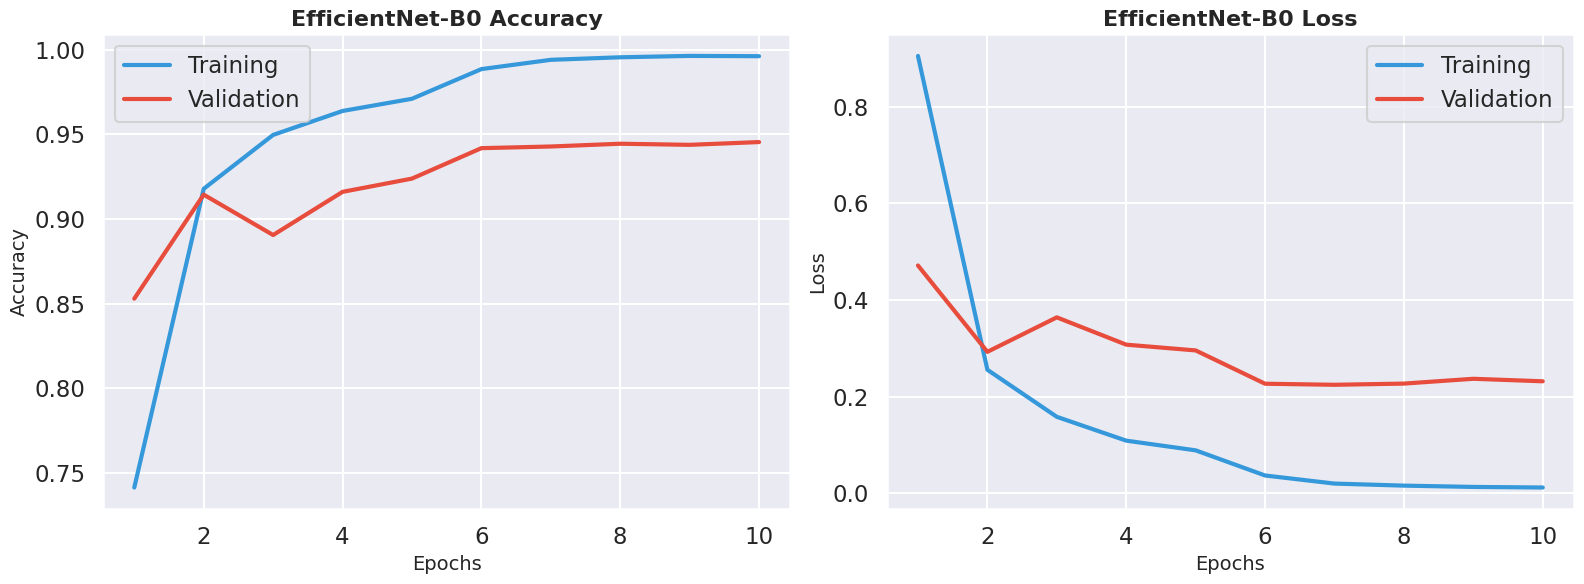

In [19]:
# Cell 12: Model 2 - EfficientNet-B0 (Crash-Proof Version)
print("--- Setting up EfficientNet-B0 ---")

# 1. Load Pretrained Model
model_effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# 2. Modify the Final Layer
# EfficientNet uses a 'classifier' block. Index 1 is the Linear layer.
num_ftrs = model_effnet.classifier[1].in_features
model_effnet.classifier[1] = nn.Linear(num_ftrs, len(class_names))

# 3. Move to GPU
model_effnet = model_effnet.to(device)

# 4. Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
# Adam is generally better for EfficientNet convergence
optimizer_effnet = optim.Adam(model_effnet.parameters(), lr=0.001)
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer_effnet, step_size=5, gamma=0.1)

# 5. Train (Auto-Save Enabled)
model_effnet, history_effnet = train_model(
    model_effnet, criterion, optimizer_effnet, exp_lr_scheduler, 
    model_name="EfficientNet-B0", num_epochs=10
)

# 6. Plot
plot_training_history(history_effnet, "EfficientNet-B0")

--- 🔍 Starting Evaluation for EfficientNet-B0 ---


Testing EfficientNet-B0:   0%|          | 0/16 [00:00<?, ?it/s]/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/JpegImagePlugin.py:846: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
Testing EfficientNet-B0: 100%|██████████| 16/16 [00:40<00:00,  2.53s/it]
/tmp/ipykernel_1350112/3656965380.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Class', data=df_acc, palette=colors, edgecolor=".2")


💾 Predictions Saved: saved_models/EfficientNet-B0_predictions.json

🏆 EfficientNet-B0 Overall Accuracy: 91.44%
📝 CLASSIFICATION REPORT
                               precision    recall  f1-score   support

               banana_healthy       0.88      0.91      0.89        75
              banana_sigatoka       0.98      1.00      0.99        95
               cassava_blight       0.94      0.85      0.89       103
              cassava_healthy       0.87      0.95      0.91        82
               cassava_mosaic       0.94      0.96      0.95       140
    corn_cercospora_leaf_spot       0.86      0.81      0.83       140
             corn_common_rust       0.96      0.99      0.97       140
                 corn_healthy       0.96      0.94      0.95       140
    corn_northern_leaf_blight       0.82      0.86      0.84       140
                    corn_smut       0.98      0.95      0.96        99
   cucumber_angular_leaf_spot       0.89      0.92      0.90        87
            

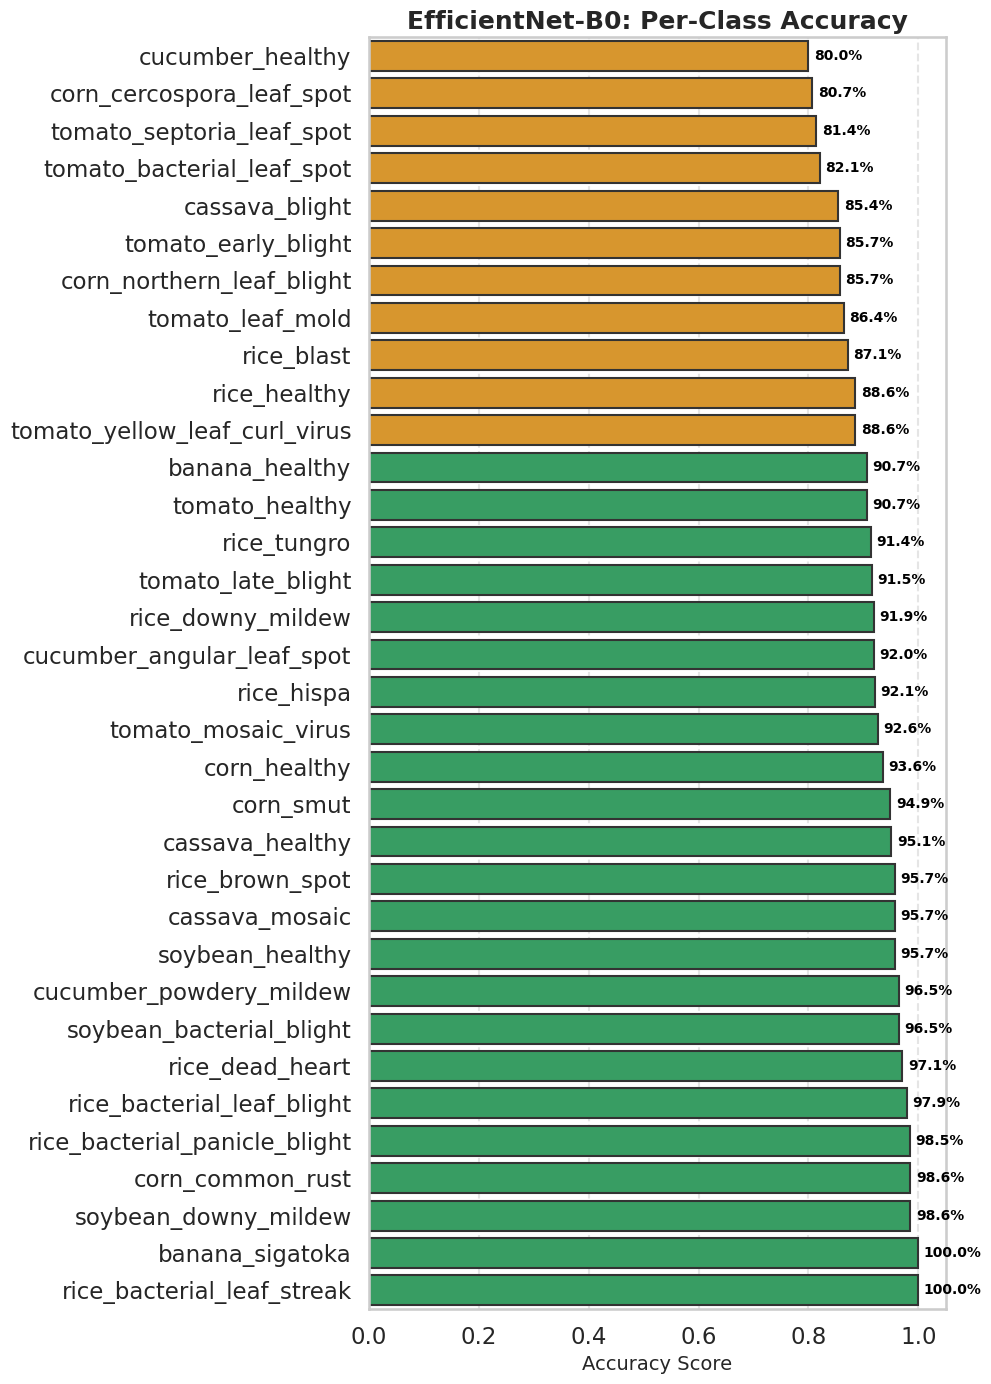


❌ TOP 10 CONFUSIONS
                   True Class             Confused With  Count
    corn_cercospora_leaf_spot corn_northern_leaf_blight     22
    corn_northern_leaf_blight corn_cercospora_leaf_spot     16
   tomato_bacterial_leaf_spot tomato_septoria_leaf_spot     14
tomato_yellow_leaf_curl_virus       tomato_mosaic_virus     11
    tomato_septoria_leaf_spot       tomato_early_blight     11
               cassava_blight            cassava_mosaic      9
                   rice_blast         rice_downy_mildew      8
          tomato_early_blight        tomato_late_blight      7
             tomato_leaf_mold        tomato_late_blight      7
   tomato_bacterial_leaf_spot       tomato_early_blight      7




In [20]:
# Cell 13: Evaluate EfficientNet-B0
# Saves predictions to 'saved_models/EfficientNet-B0_predictions.json'
y_true_eff, y_pred_eff = evaluate_model(model_effnet, "EfficientNet-B0")

--- Setting up MobileNetV2 ---
🚀 Training MobileNetV2 on cuda:3 for 10 epochs...
------------------------------------------------------------


Epoch 1/10 [TRAIN]:   0%|          | 0/68 [00:00<?, ?it/s]/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/JpegImagePlugin.py:846: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/JpegImagePlugin.py:846: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_

	TRAIN Loss: 2.6342 | Acc: 0.3314


Epoch 1/10 [VAL]: 100%|██████████| 12/12 [00:05<00:00,  2.04it/s, loss=1.6467]


	VAL Loss: 1.7075 | Acc: 0.5866


...

	VAL Loss: 0.5698 | Acc: 0.8353


Epoch 10/10 [TRAIN]:  49%|████▊     | 33/68 [00:12<00:06,  5.07it/s, loss=0.5563]/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/JpegImagePlugin.py:846: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
Epoch 10/10 [TRAIN]: 100%|██████████| 68/68 [00:22<00:00,  3.04it/s, loss=0.5730]


	TRAIN Loss: 0.5073 | Acc: 0.8580


Epoch 10/10 [VAL]: 100%|██████████| 12/12 [00:04<00:00,  2.43it/s, loss=0.5961]


	VAL Loss: 0.5632 | Acc: 0.8340
------------------------------------------------------------
Training complete in 4m 34s
Best Val Acc: 0.8353
💾 Model Saved: saved_models/MobileNetV2.pth
💾 History Saved: saved_models/MobileNetV2_history.json


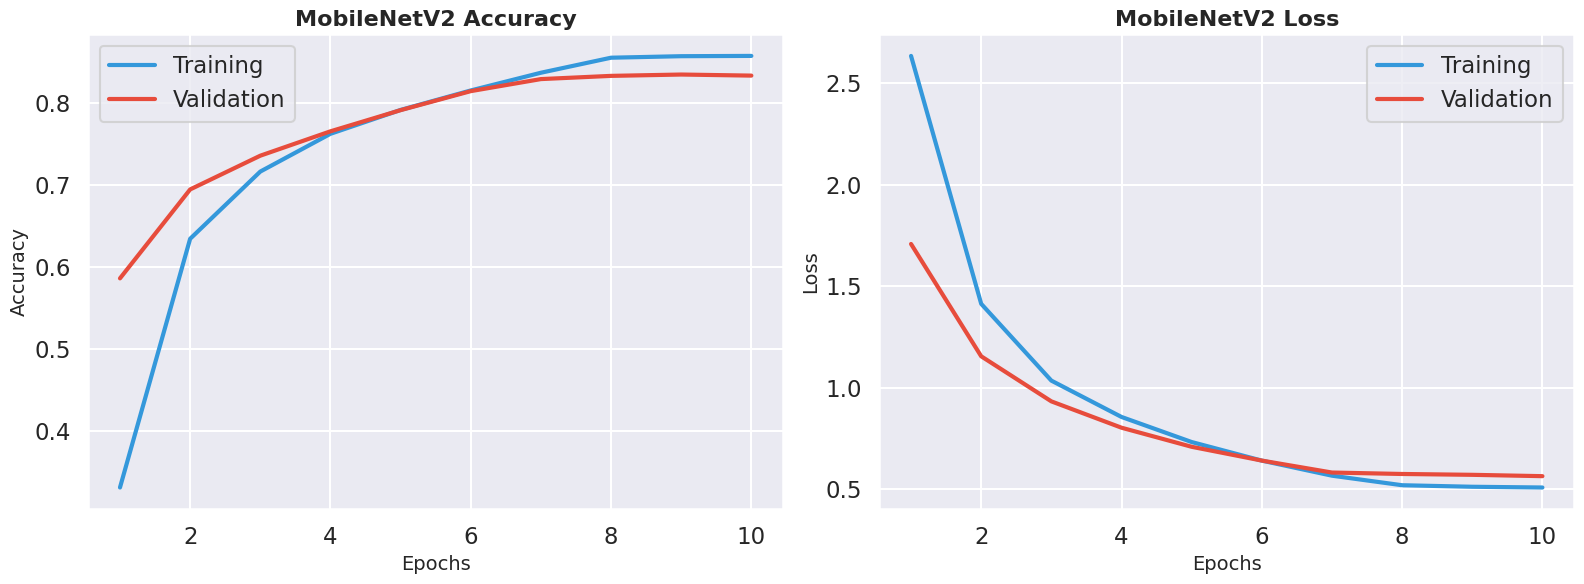

In [24]:
# Cell 15: Model 3 - MobileNetV2 (Crash-Proof Version)
print("--- Setting up MobileNetV2 ---")

# 1. Load Pretrained Model
model_mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# 2. Modify the Final Layer
# MobileNet also uses 'classifier[1]'
num_ftrs = model_mobilenet.classifier[1].in_features
model_mobilenet.classifier[1] = nn.Linear(num_ftrs, len(class_names))

# 3. Move to GPU
model_mobilenet = model_mobilenet.to(device)

# 4. Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
# SGD with momentum works well for MobileNet
optimizer_mobile = optim.SGD(model_mobilenet.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer_mobile, step_size=7, gamma=0.1)

# 5. Train (Auto-Save Enabled)
model_mobilenet, history_mobile = train_model(
    model_mobilenet, criterion, optimizer_mobile, exp_lr_scheduler, 
    model_name="MobileNetV2", num_epochs=10
)

# 6. Plot
plot_training_history(history_mobile, "MobileNetV2")

--- 🔍 Starting Evaluation for MobileNetV2 ---


Testing MobileNetV2:   0%|          | 0/16 [00:00<?, ?it/s]/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/home/jupyter-sreegovind_sair_24-fe2d8/.local/lib/python3.9/site-packages/PIL/JpegImagePlugin.py:846: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
Testing MobileNetV2: 100%|██████████| 16/16 [00:40<00:00,  2.50s/it]
/tmp/ipykernel_1350112/3656965380.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Class', data=df_acc, palette=colors, edgecolor=".2")


💾 Predictions Saved: saved_models/MobileNetV2_predictions.json

🏆 MobileNetV2 Overall Accuracy: 80.75%
📝 CLASSIFICATION REPORT
                               precision    recall  f1-score   support

               banana_healthy       0.78      0.91      0.84        75
              banana_sigatoka       0.93      1.00      0.96        95
               cassava_blight       0.87      0.78      0.82       103
              cassava_healthy       0.74      0.90      0.81        82
               cassava_mosaic       0.89      0.88      0.88       140
    corn_cercospora_leaf_spot       0.82      0.73      0.77       140
             corn_common_rust       0.95      0.87      0.91       140
                 corn_healthy       0.94      0.86      0.90       140
    corn_northern_leaf_blight       0.74      0.84      0.79       140
                    corn_smut       0.93      0.93      0.93        99
   cucumber_angular_leaf_spot       0.76      0.83      0.79        87
             cucumbe

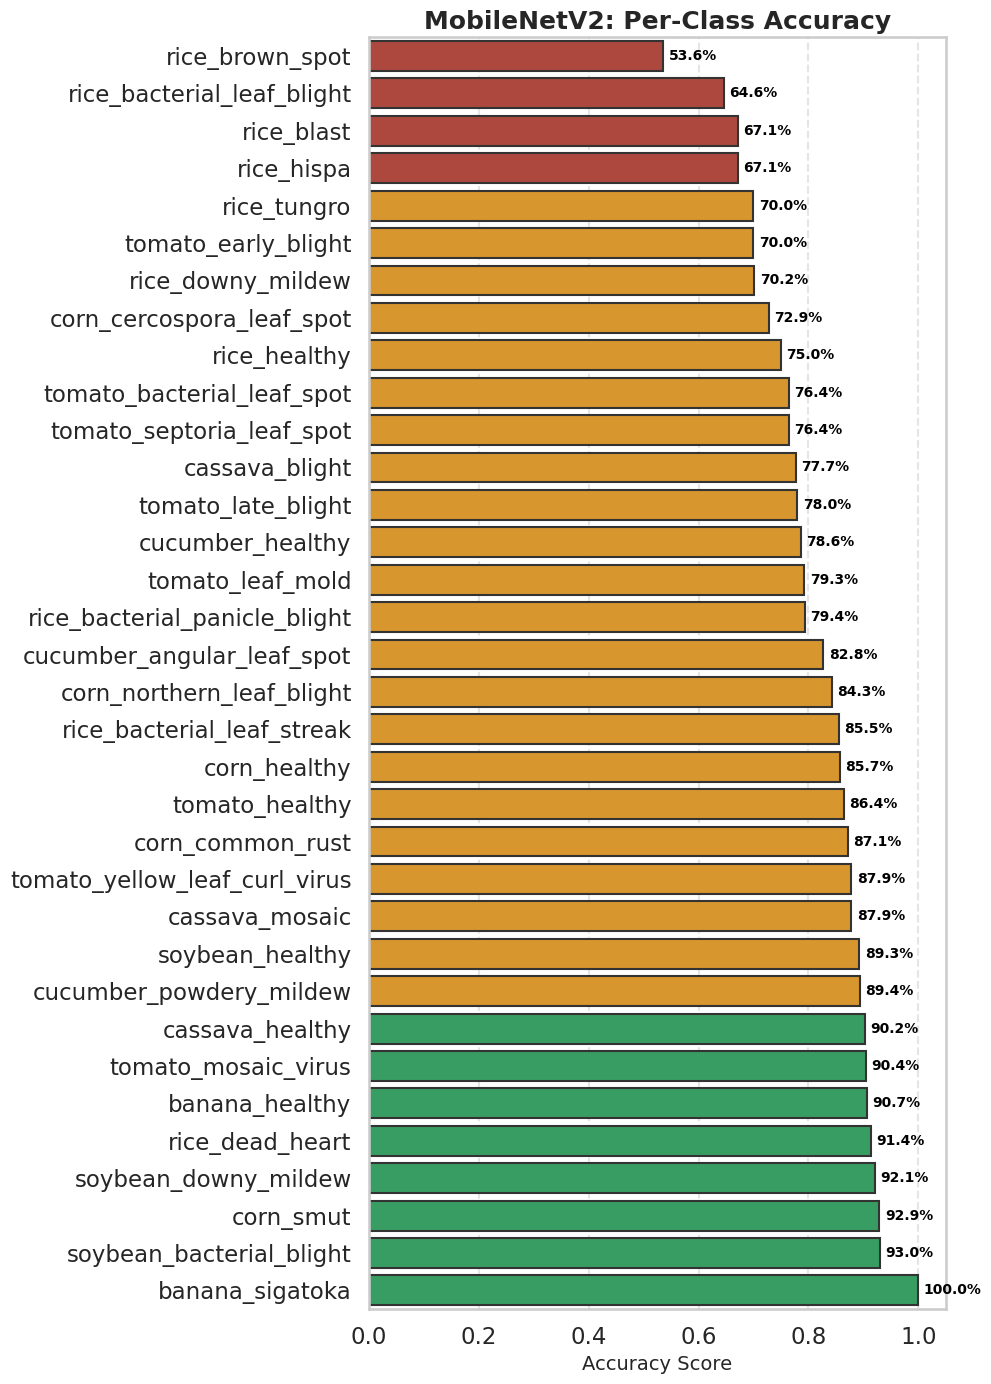


❌ TOP 10 CONFUSIONS
                   True Class             Confused With  Count
    corn_cercospora_leaf_spot corn_northern_leaf_blight     27
              rice_brown_spot         rice_downy_mildew     21
          tomato_early_blight        tomato_late_blight     21
    corn_northern_leaf_blight corn_cercospora_leaf_spot     17
                   rice_hispa              rice_healthy     16
              rice_brown_spot                rice_blast     15
rice_bacterial_panicle_blight           rice_dead_heart     14
                   rice_blast               rice_tungro     14
          tomato_early_blight tomato_septoria_leaf_spot     13
   tomato_bacterial_leaf_spot       tomato_early_blight     13




In [25]:
# Cell 16: Evaluate MobileNetV2
# Saves predictions to 'saved_models/MobileNetV2_predictions.json'
y_true_mobile, y_pred_mobile = evaluate_model(model_mobilenet, "MobileNetV2")

📂 Loading data from saved_models...

🏆 FINAL TEST RESULTS COMPARISON
          Model  Test Accuracy  F1-Score  Precision   Recall
EfficientNet-B0       0.914404  0.914538   0.915985 0.914404
       ResNet50       0.824162  0.824759   0.830512 0.824162
    MobileNetV2       0.807532  0.808999   0.817474 0.807532


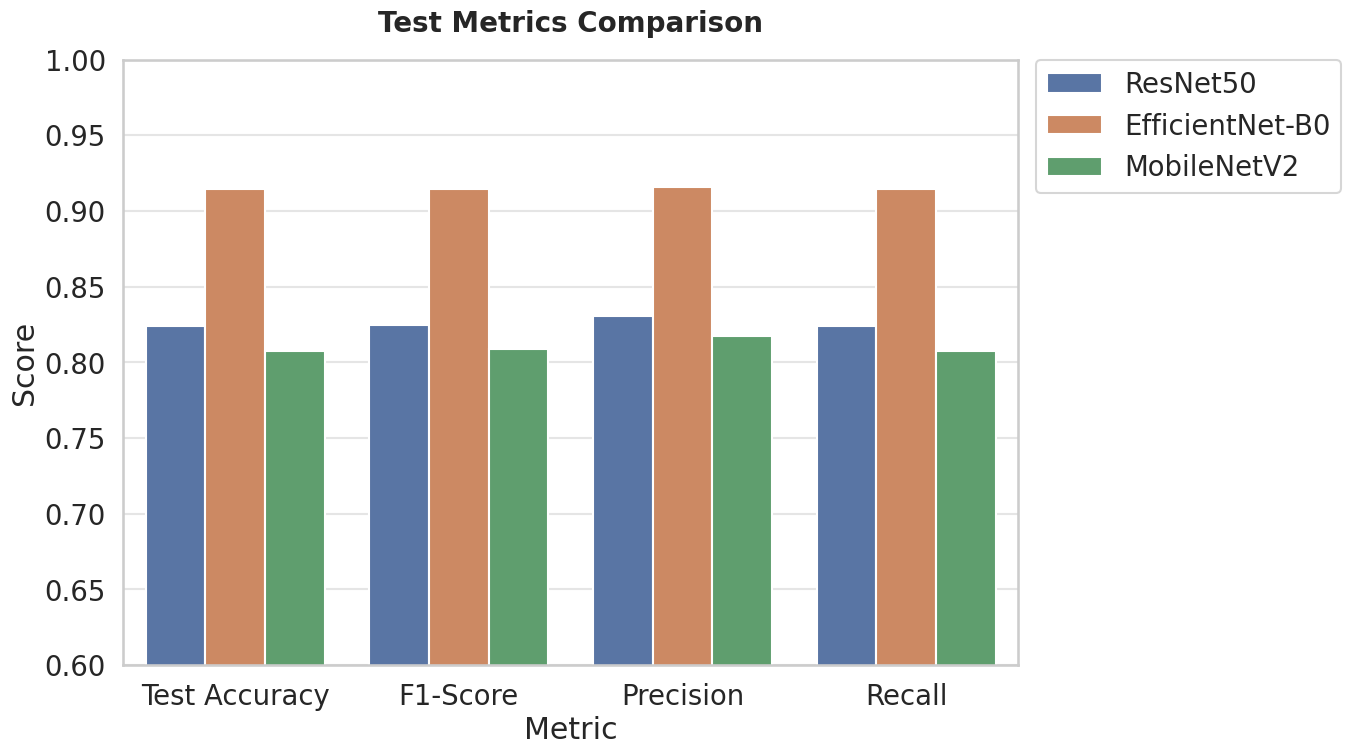



📈 TRAINING DYNAMICS




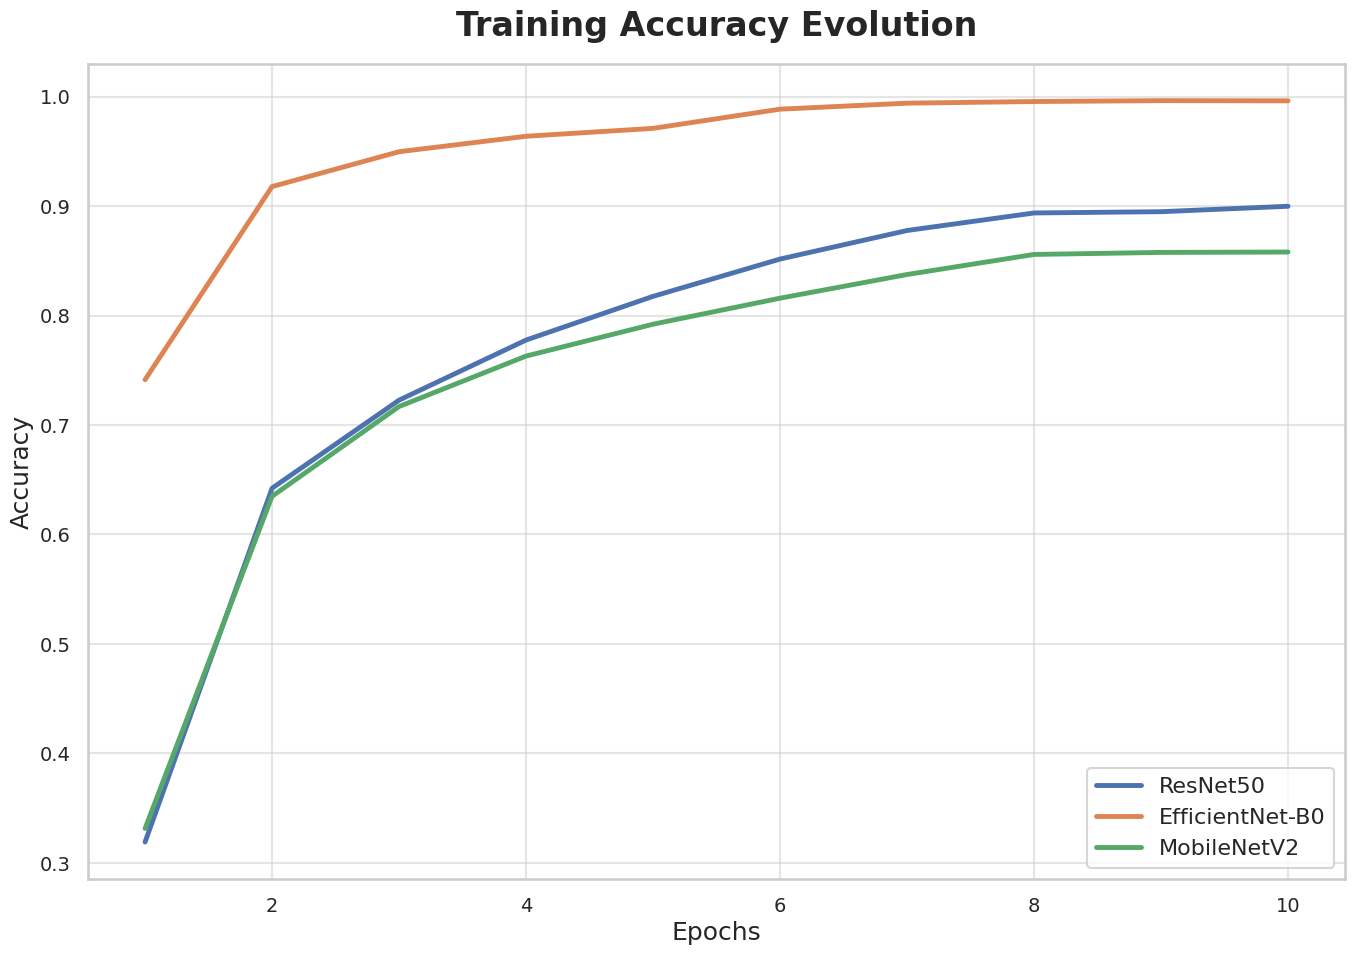

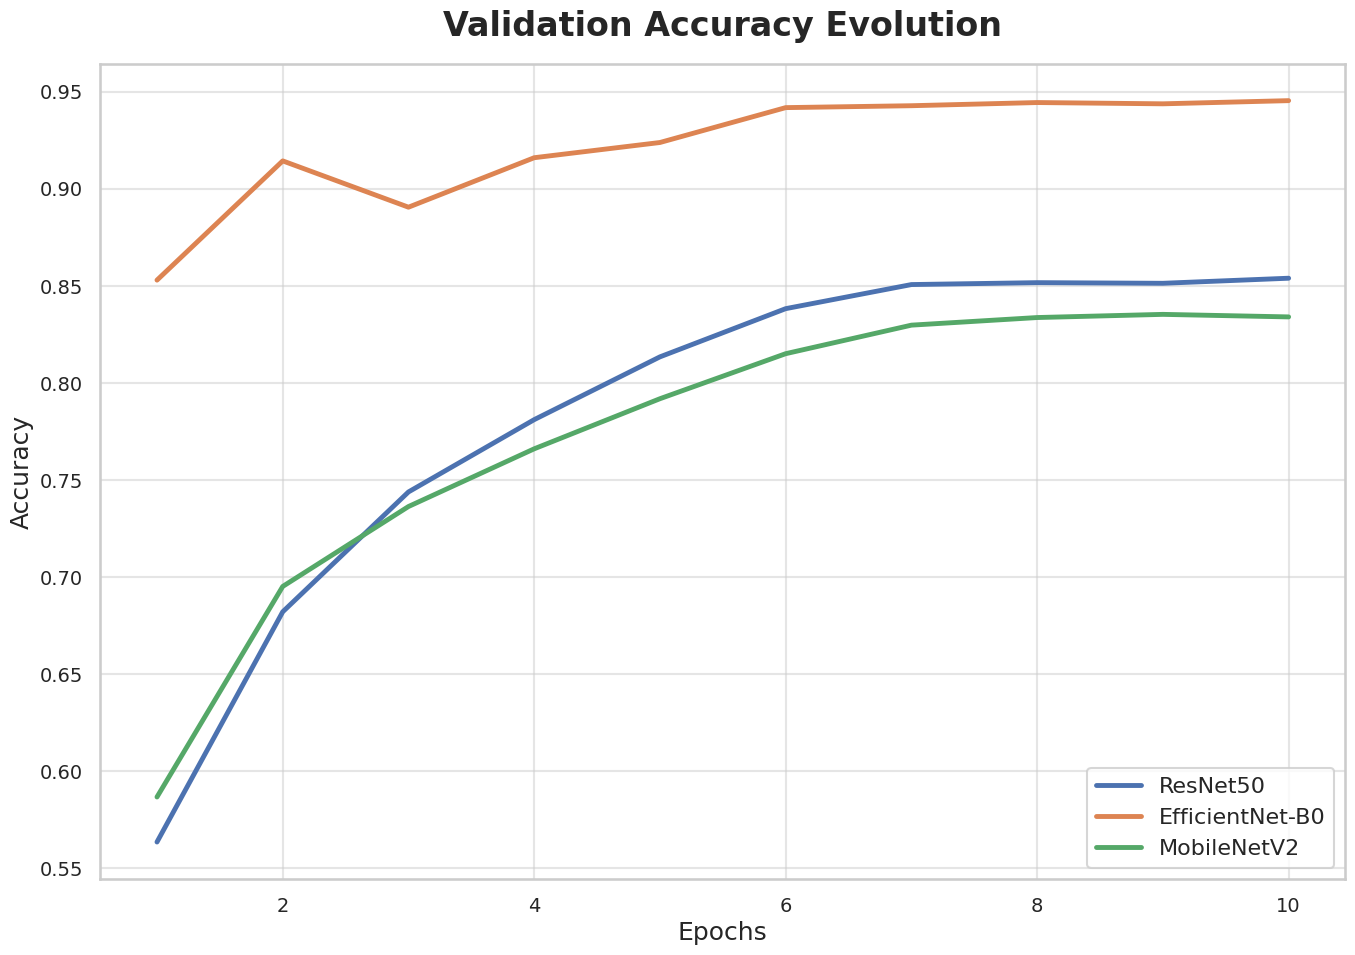

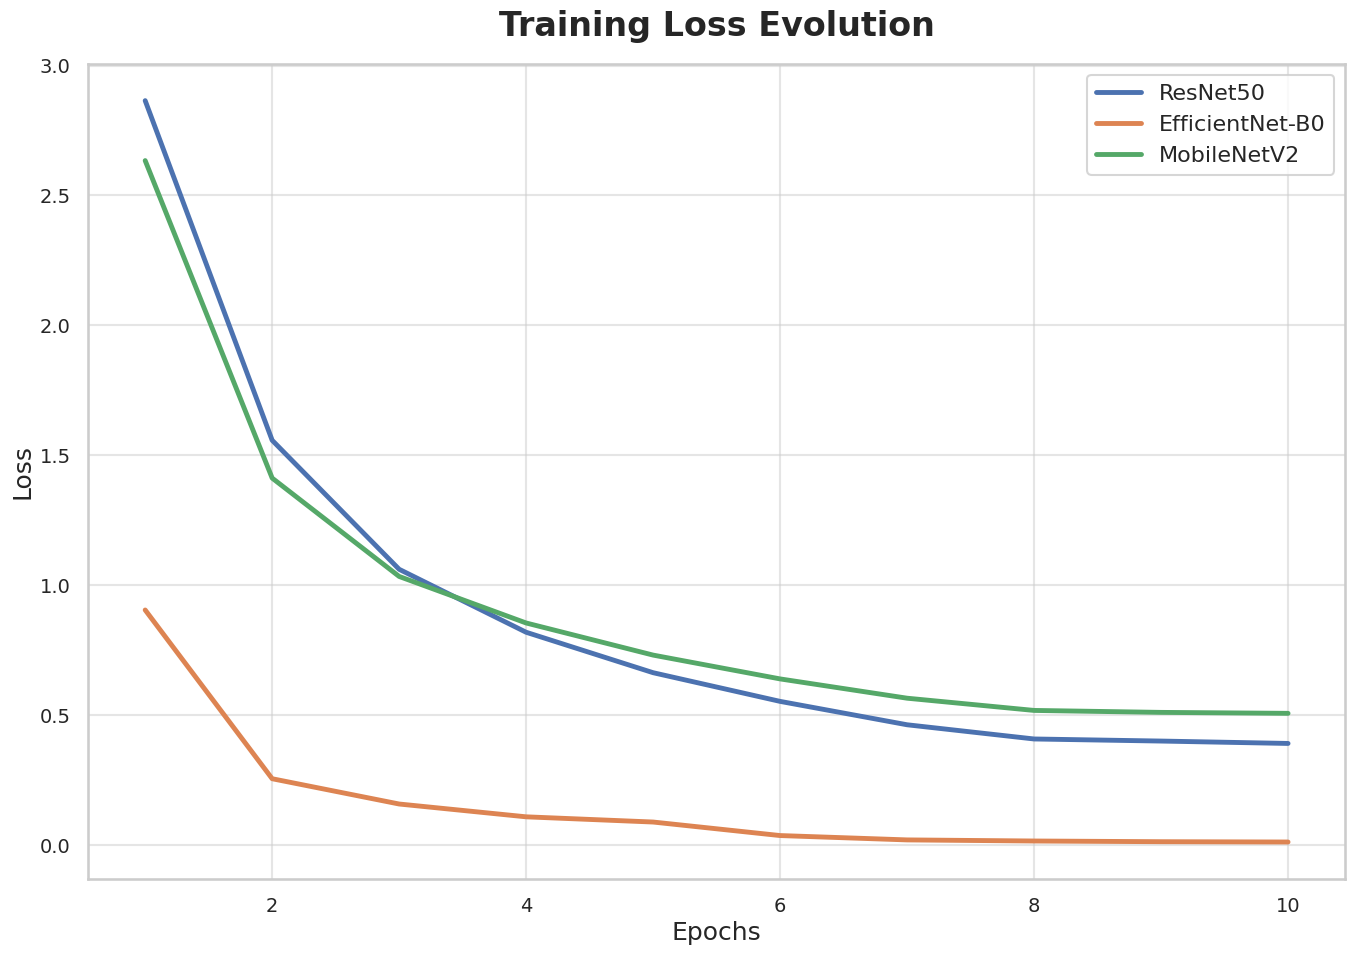

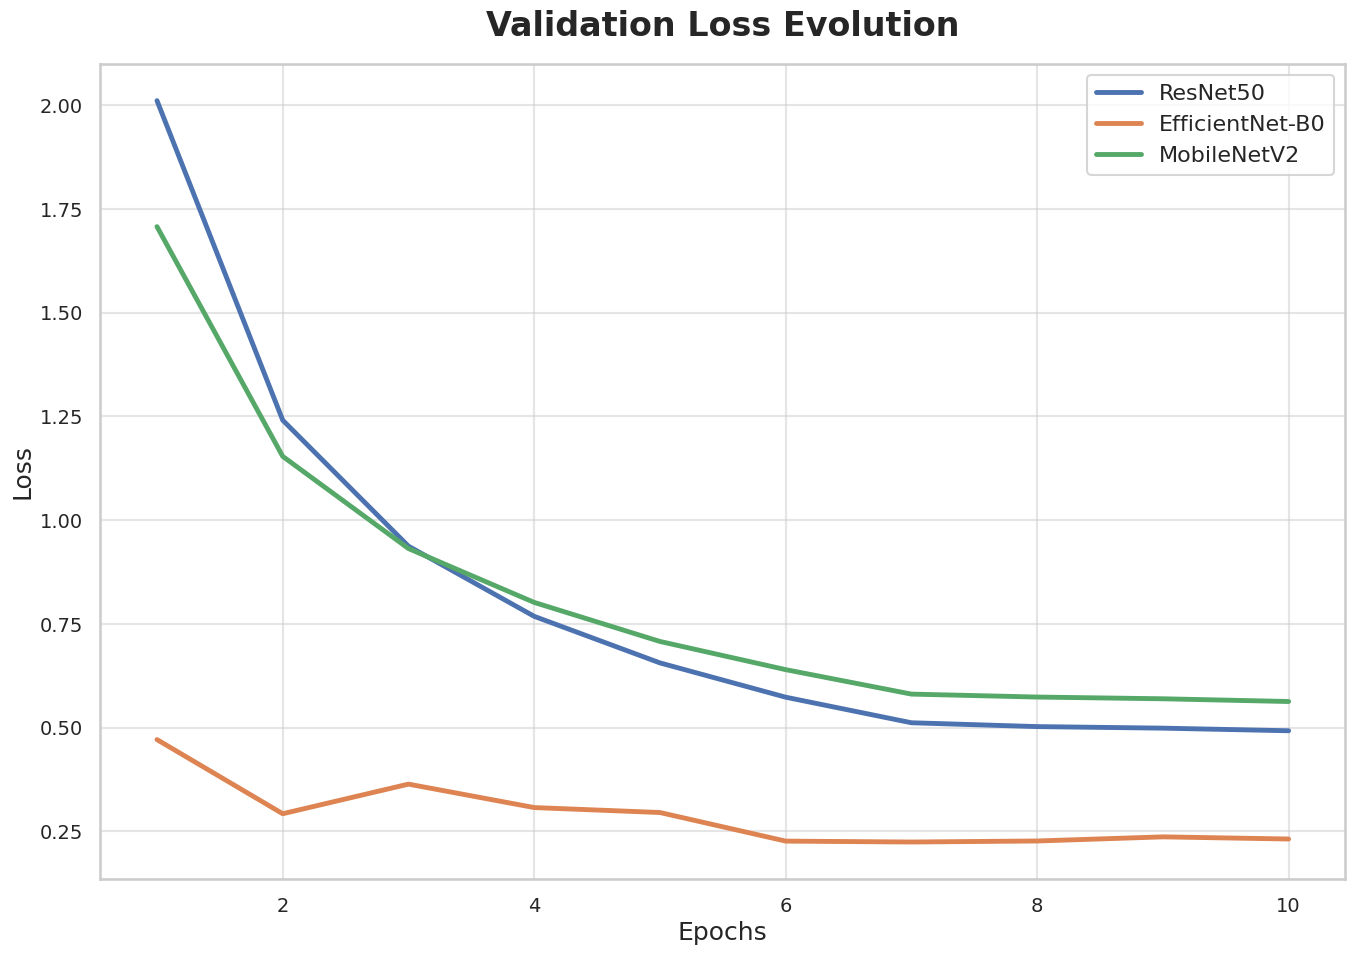

In [31]:
# Cell 17: Comparative Analysis (Big, Readable, Stacked Plots)
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Configuration
SAVE_DIR = "saved_models"
MODELS = ["ResNet50", "EfficientNet-B0", "MobileNetV2"]

# Set style for "Big & Readable"
sns.set_theme(style="whitegrid", context="talk", font_scale=1.2)
plt.rcParams['lines.linewidth'] = 3.5  # Thicker lines
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5

def load_metrics():
    """Loads history and predictions from disk."""
    histories = {}
    test_metrics = []

    print(f"📂 Loading data from {SAVE_DIR}...")
    
    for model_name in MODELS:
        # 1. Load History
        hist_path = os.path.join(SAVE_DIR, f"{model_name}_history.json")
        if os.path.exists(hist_path):
            with open(hist_path, 'r') as f:
                histories[model_name] = json.load(f)
        else:
            print(f"⚠️ Warning: History not found for {model_name}")

        # 2. Load Predictions
        pred_path = os.path.join(SAVE_DIR, f"{model_name}_predictions.json")
        if os.path.exists(pred_path):
            with open(pred_path, 'r') as f:
                data = json.load(f)
                y_true = data['y_true']
                y_pred = data['y_pred']
                
                test_metrics.append({
                    "Model": model_name,
                    "Test Accuracy": accuracy_score(y_true, y_pred),
                    "F1-Score": f1_score(y_true, y_pred, average='weighted'),
                    "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
                    "Recall": recall_score(y_true, y_pred, average='weighted')
                })
            
    return histories, pd.DataFrame(test_metrics)

# --- EXECUTION ---
histories, df_results = load_metrics()

# ==========================================
# 1. TEST METRICS TABLE & BAR CHART
# ==========================================
print("\n" + "="*40)
print("🏆 FINAL TEST RESULTS COMPARISON")
print("="*40)
print(df_results.sort_values(by="Test Accuracy", ascending=False).to_string(index=False))

# Melt for bar chart
df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 8))
sns.barplot(x="Metric", y="Score", hue="Model", data=df_melted, palette="deep")
plt.title("Test Metrics Comparison", fontsize=20, fontweight='bold', pad=20)
plt.ylim(0.6, 1.0) 
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

# ==========================================
# 2. TRAINING DYNAMICS (One by One)
# ==========================================
print("\n\n" + "="*40)
print("📈 TRAINING DYNAMICS")
print("="*40+"\n\n")

def plot_metric_comparison(metric_key, title, ylabel):
    plt.figure(figsize=(14, 10)) # Big Canvas
    
    for model_name, history in histories.items():
        if metric_key in history:
            data = history[metric_key]
            epochs = range(1, len(data) + 1)
            sns.lineplot(x=epochs, y=data, label=model_name)
    
    plt.title(title, fontsize=24, fontweight='bold', pad=20)
    plt.xlabel("Epochs", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=16, loc="best")
    plt.tight_layout()
    plt.show()

# Plot 1: Training Accuracy
plot_metric_comparison('train_acc', 'Training Accuracy Evolution', 'Accuracy')
print("\n\n")
# Plot 2: Validation Accuracy
plot_metric_comparison('val_acc', 'Validation Accuracy Evolution', 'Accuracy')
print("\n\n")
# Plot 3: Training Loss
plot_metric_comparison('train_loss', 'Training Loss Evolution', 'Loss')
print("\n\n")
# Plot 4: Validation Loss
plot_metric_comparison('val_loss', 'Validation Loss Evolution', 'Loss')